# Seurat batch correction test

In [1]:
here::i_am("rna/trajectories/infer_trajectory.R")

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(uwot))
suppressPackageStartupMessages(library(Seurat))

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code

Warning message:
“package ‘destiny’ was built under R version 4.1.3”
Warning message:
“package ‘Seurat’ was built under R version 4.1.2”


In [2]:
## START TEST ##
args <- list()
args$sce <-file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
args$metadataRNA <- file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$metadataATAC <- file.path(io$basedir, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')
args$trajectory_name <- "epiblast_blood"
args$celltype_label <- "celltype"
args$outdir <- file.path(io$basedir,"results/epiblast_blood")

args$batch_variable = 'sample'
args$features = 3000
args$npcs <- 25
args$min_dist = 0.3
args$n_neighbors = 25
args$seed = 1234
args$sample <- c('E7.5_rep1','E7.5_rep2','E7.75_rep1','E8.0_rep1','E8.0_rep2','E8.5_rep1','E8.5_rep2','E8.75_rep1','E8.75_rep2')
## END TEST ##

# I/O
dir.create(args$outdir, showWarnings=F, recursive=T)

# Trajectory 
opts$celltypes = c("Epiblast",
                    "Primitive_Streak" ,
                    "Nascent_mesoderm",
                    "ExE_mesoderm",
                    "Mixed_mesoderm",
                    "Allantois",
                    "Mesenchyme",
                    "Haematoendothelial_progenitors",
                    "Endothelium",
                    "Blood_progenitors_1",
                    "Blood_progenitors_2",
                    "Erythroid1",
                    "Erythroid2",
                    "Erythroid3")

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

In [3]:
unique(fread(args$metadataRNA)$celltype)

[1] NA                               "Caudal_epiblast"               
 [3] "ExE_ectoderm"                   "Mixed_mesoderm"                
 [5] "Primitive_Streak"               "Parietal_endoderm"             
 [7] "Somitic_mesoderm"               "Gut"                           
 [9] "Blood_progenitors_1"            "Rostral_neurectoderm"          
[11] "Visceral_endoderm"              "ExE_endoderm"                  
[13] "Nascent_mesoderm"               "Haematoendothelial_progenitors"
[15] "Def._endoderm"                  "Caudal_Mesoderm"               
[17] "Epiblast"                       "Mesenchyme"                    
[19] "Blood_progenitors_2"            "Paraxial_mesoderm"             
[21] "Anterior_Primitive_Streak"      "Surface_ectoderm"              
[23] "Pharyngeal_mesoderm"            "Notochord"                     
[25] "Intermediate_mesoderm"          "PGC"                           
[27] "ExE_mesoderm"                   "Forebrain_Midbrain_Hindbrain"  
[29] "Spinal_cord"                    "Caudal_neurectoderm"           
[31] "Allantois"                      "Endothelium"                   
[33] "Neural_crest"                   "Cardiomyocytes"                
[35] "Erythroid1"                     "NMP"                           
[37] "Erythroid2"                     "Erythroid3"

In [4]:
##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadataRNA) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE] %>%
    merge(.,fread(args$metadataATAC)[,c('cell', 'pass_atacQC')], by='cell') %>%
    .[pass_atacQC==TRUE]

stopifnot(args$celltype_label%in%colnames(sample_metadata))
sample_metadata <- sample_metadata   %>%
  .[,celltype:=eval(as.name(args$celltype_label))] %>%
  .[celltype%in%opts$celltypes] %>%
  .[,celltype:=factor(celltype,levels=opts$celltypes)] %>%
  .[sample%in% args$sample]

table(sample_metadata$celltype)

# Save
#fwrite(sample_metadata, file.path(args$outdir,sprintf("%s_sample_metadata.txt.gz",args$trajectory_name)))


                      Epiblast               Primitive_Streak 
                           984                            542 
              Nascent_mesoderm                   ExE_mesoderm 
                          1327                           1173 
                Mixed_mesoderm                      Allantois 
                           265                            653 
                    Mesenchyme Haematoendothelial_progenitors 
                          3123                            913 
                   Endothelium            Blood_progenitors_1 
                           666                            230 
           Blood_progenitors_2                     Erythroid1 
                           565                           1119 
                    Erythroid2                     Erythroid3 
                           939                            187 

In [5]:
#########################
## Load RNA expression ##
#########################
  
sce <- load_SingleCellExperiment(
  file = args$sce, 
  normalise = TRUE, 
  cells = sample_metadata$cell, 
  remove_non_expressed_genes = TRUE
)

colData(sce) <- sample_metadata %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()

In [6]:
#################
## Seurat rPCA ##
#################

In [7]:
seurat = as.Seurat(sce)

In [8]:
seurat

An object of class Seurat 
20519 features across 12686 samples within 1 assay 
Active assay: RNA (20519 features, 0 variable features)

In [24]:
# split the dataset into a list of two seurat objects (stim and CTRL)
seurat.list <- SplitObject(seurat, split.by = "stage")

# normalize and identify variable features for each dataset independently
seurat.list <- lapply(X = seurat.list, FUN = function(x) {
    x <- NormalizeData(x)
    x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = 2000)
})

# select features that are repeatedly variable across datasets for integration run PCA on each
# dataset using these features
features <- SelectIntegrationFeatures(object.list = seurat.list)
seurat.list <- lapply(X = seurat.list, FUN = function(x) {
    x <- ScaleData(x, features = features, verbose = FALSE)
    x <- RunPCA(x, features = features, verbose = FALSE)
})

In [25]:
seurat.anchors <- FindIntegrationAnchors(object.list = seurat.list, anchor.features = features, reduction = "rpca")
# this command creates an 'integrated' data assay
seurat.combined <- IntegrateData(anchorset = seurat.anchors)

Scaling features for provided objects

Computing within dataset neighborhoods

Finding all pairwise anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 907 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 890 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 308 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 694 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 282 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 3113 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 527 anchors

Projecting new data onto SVD

Projecting new data 

In [26]:
# specify that we will perform downstream analysis on the corrected data note that the
# original unmodified data still resides in the 'RNA' assay
DefaultAssay(seurat.combined) <- "integrated"

# Run the standard workflow for visualization and clustering
seurat.combined <- ScaleData(seurat.combined, verbose = FALSE)
seurat.combined <- RunPCA(seurat.combined, npcs = 30, verbose = FALSE)
seurat.combined <- RunUMAP(seurat.combined, reduction = "pca", dims = 1:30)
seurat.combined <- FindNeighbors(seurat.combined, reduction = "pca", dims = 1:30)
seurat.combined <- FindClusters(seurat.combined, resolution = 0.5)

12:25:39 UMAP embedding parameters a = 0.9922 b = 1.112

12:25:39 Read 12686 rows and found 30 numeric columns

12:25:39 Using Annoy for neighbor search, n_neighbors = 30

12:25:39 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:25:40 Writing NN index file to temp file /tmp/RtmpsHNVoc/file112d364657074

12:25:40 Searching Annoy index using 1 thread, search_k = 3000

12:25:43 Annoy recall = 100%

12:25:44 Commencing smooth kNN distance calibration using 1 thread

12:25:46 Initializing from normalized Laplacian + noise

12:25:46 Commencing optimization for 200 epochs, with 536616 positive edges

12:26:01 Optimization finished

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12686
Number of edges: 481927

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9046
Number of communities: 14
Elapsed time: 1 seconds


In [27]:
seurat.combined

An object of class Seurat 
22519 features across 12686 samples within 2 assays 
Active assay: integrated (2000 features, 2000 variable features)
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

In [28]:
head(seurat.combined@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,barcode,sample,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,genotype,pass_rnaQC,doublet_score,doublet_call,celltype,celltype.score,closest.cell,pass_atacQC,integrated_snn_res.0.5,seurat_clusters
,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<lgl>,<fct>,<fct>
E7.5_rep1#AAACAGCCATCCTGAA-1,E7.5,6034,2677,AAACAGCCATCCTGAA-1,E7.5_rep1,21.63,6.36,E7.5,NA,TRUE,0.12,FALSE,Mixed_mesoderm,0.64,cell_87889,TRUE,1,1
E7.5_rep1#AAACAGCCATGCTATG-1,E7.5,11990,3982,AAACAGCCATGCTATG-1,E7.5_rep1,24.96,8.14,E7.5,NA,TRUE,0.40,FALSE,Primitive_Streak,0.60,cell_103930,TRUE,5,5
E7.5_rep1#AAACATGCAGGATAAC-1,E7.5,11540,4153,AAACATGCAGGATAAC-1,E7.5_rep1,11.63,5.62,E7.5,NA,TRUE,0.21,FALSE,Blood_progenitors_1,0.72,cell_22618,TRUE,9,9
E7.5_rep1#AAACCGGCAACCCTAA-1,E7.5,12800,4426,AAACCGGCAACCCTAA-1,E7.5_rep1,18.12,6.65,E7.5,NA,TRUE,0.43,FALSE,Nascent_mesoderm,1.00,cell_3500,TRUE,1,1
E7.5_rep1#AAACCGGCAACCTAAT-1,E7.5,8154,3407,AAACCGGCAACCTAAT-1,E7.5_rep1,9.92,5.47,E7.5,NA,TRUE,0.24,FALSE,Haematoendothelial_progenitors,0.76,cell_83273,TRUE,9,9
E7.5_rep1#AAACGGATCACGCCAA-1,E7.5,8718,3347,AAACGGATCACGCCAA-1,E7.5_rep1,21.06,6.78,E7.5,NA,TRUE,0.27,FALSE,Primitive_Streak,0.72,cell_103930,TRUE,5,5


In [29]:
# Visualization
options(repr.plot.width=25, repr.plot.height=8)
p1 <- DimPlot(seurat.combined, reduction = "umap", group.by = "celltype") +
        scale_colour_manual(values=opts$celltype.colors)
p2 <- DimPlot(seurat.combined, reduction = "umap", group.by = "sample", label = TRUE,
    repel = TRUE)

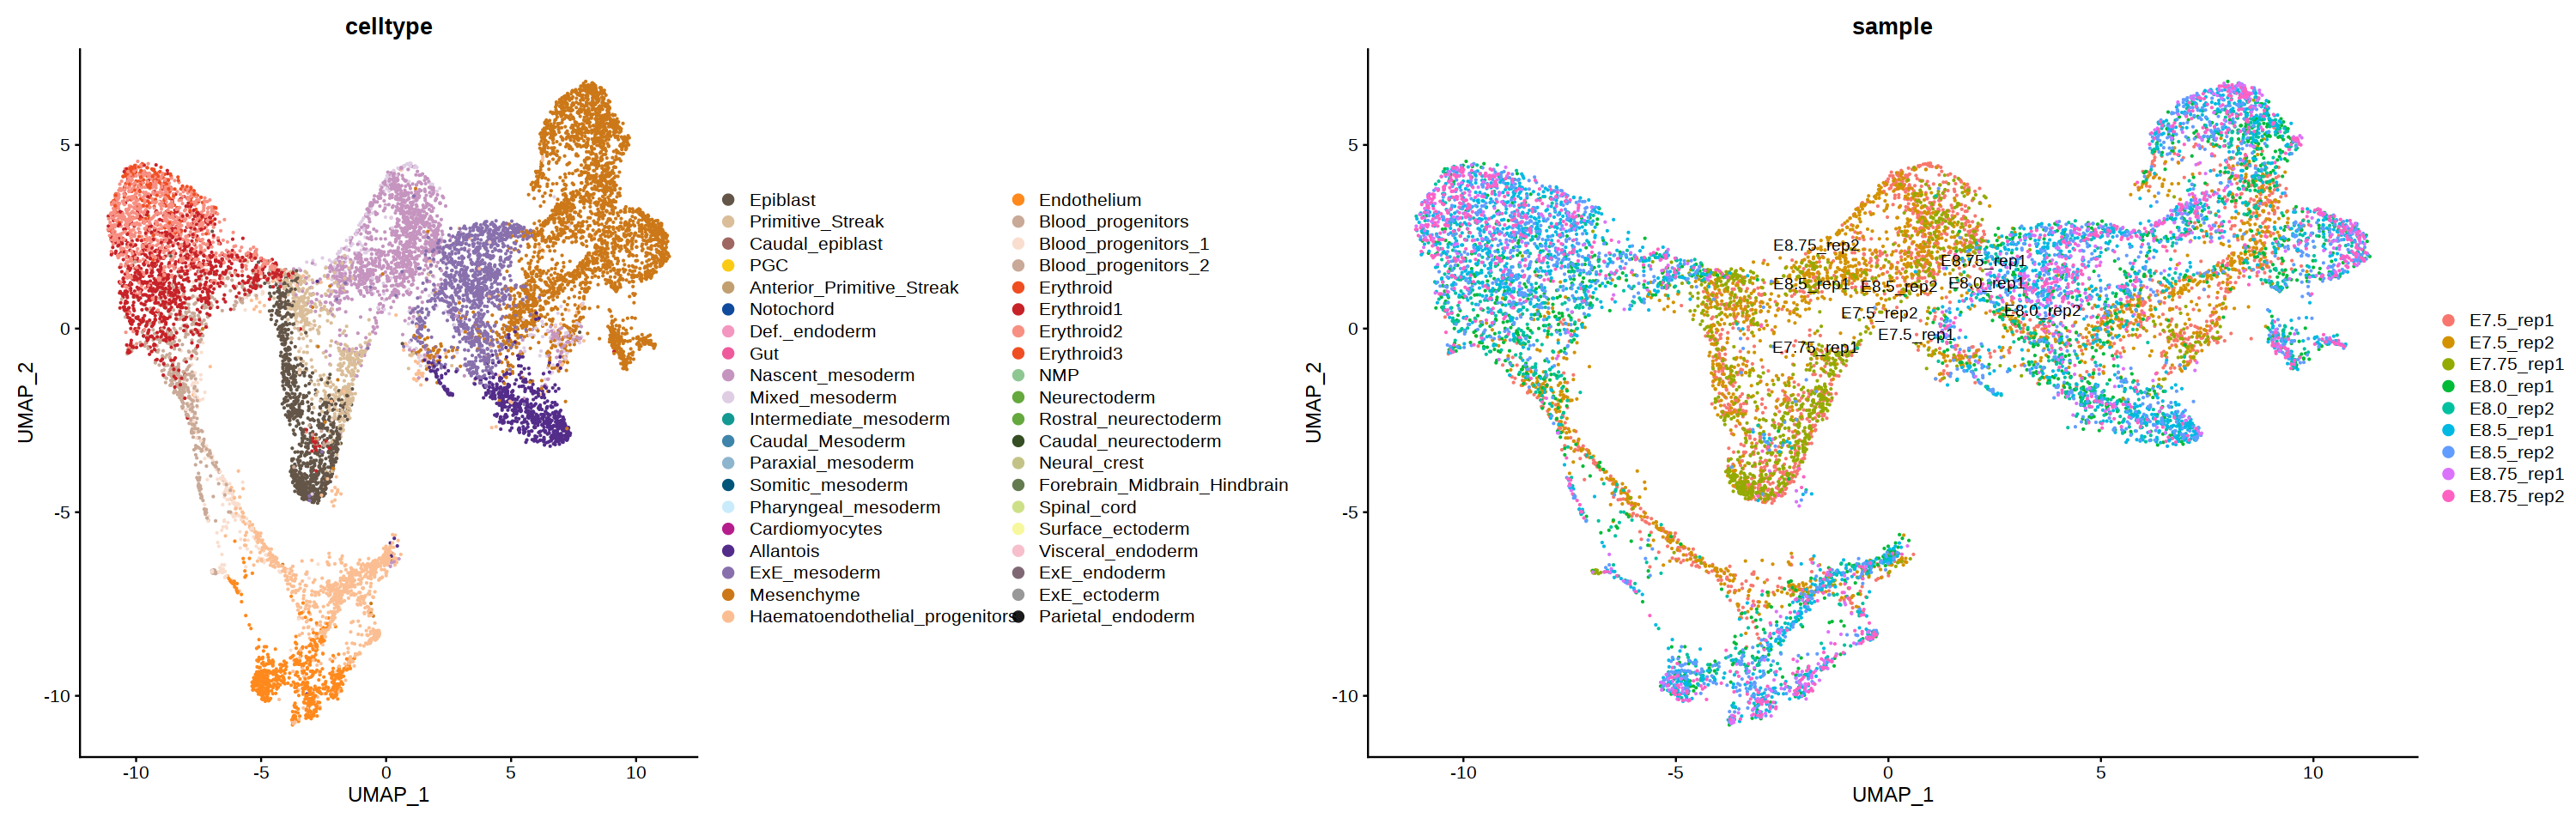

In [30]:
ggarrange(p1, p2)

In [31]:
# Run the standard workflow for visualization and clustering
seurat <- NormalizeData(seurat)
seurat <- FindVariableFeatures(seurat, selection.method = "vst", nfeatures = 2000)
seurat <- ScaleData(seurat, verbose = FALSE)
seurat <- RunPCA(seurat, npcs = 30, verbose = FALSE)
seurat <- RunUMAP(seurat, reduction = "pca", dims = 1:30)
seurat <- FindNeighbors(seurat, reduction = "pca", dims = 1:30)
seurat <- FindClusters(seurat, resolution = 0.5)

13:31:08 UMAP embedding parameters a = 0.9922 b = 1.112

13:31:08 Read 12686 rows and found 30 numeric columns

13:31:08 Using Annoy for neighbor search, n_neighbors = 30

13:31:08 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:31:09 Writing NN index file to temp file /tmp/RtmpsHNVoc/file112d317ce74fa

13:31:09 Searching Annoy index using 1 thread, search_k = 3000

13:31:12 Annoy recall = 100%

13:31:13 Commencing smooth kNN distance calibration using 1 thread

13:31:15 Initializing from normalized Laplacian + noise

13:31:15 Commencing optimization for 200 epochs, with 522662 positive edges

13:31:30 Optimization finished

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12686
Number of edges: 449569

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9250
Number of communities: 16
Elapsed time: 1 seconds


In [32]:
# Visualization
options(repr.plot.width=25, repr.plot.height=8)
p1 <- DimPlot(seurat, reduction = "umap", group.by = "celltype") +
        scale_colour_manual(values=opts$celltype.colors)
p2 <- DimPlot(seurat, reduction = "umap", group.by = "sample", label = TRUE,
    repel = TRUE)

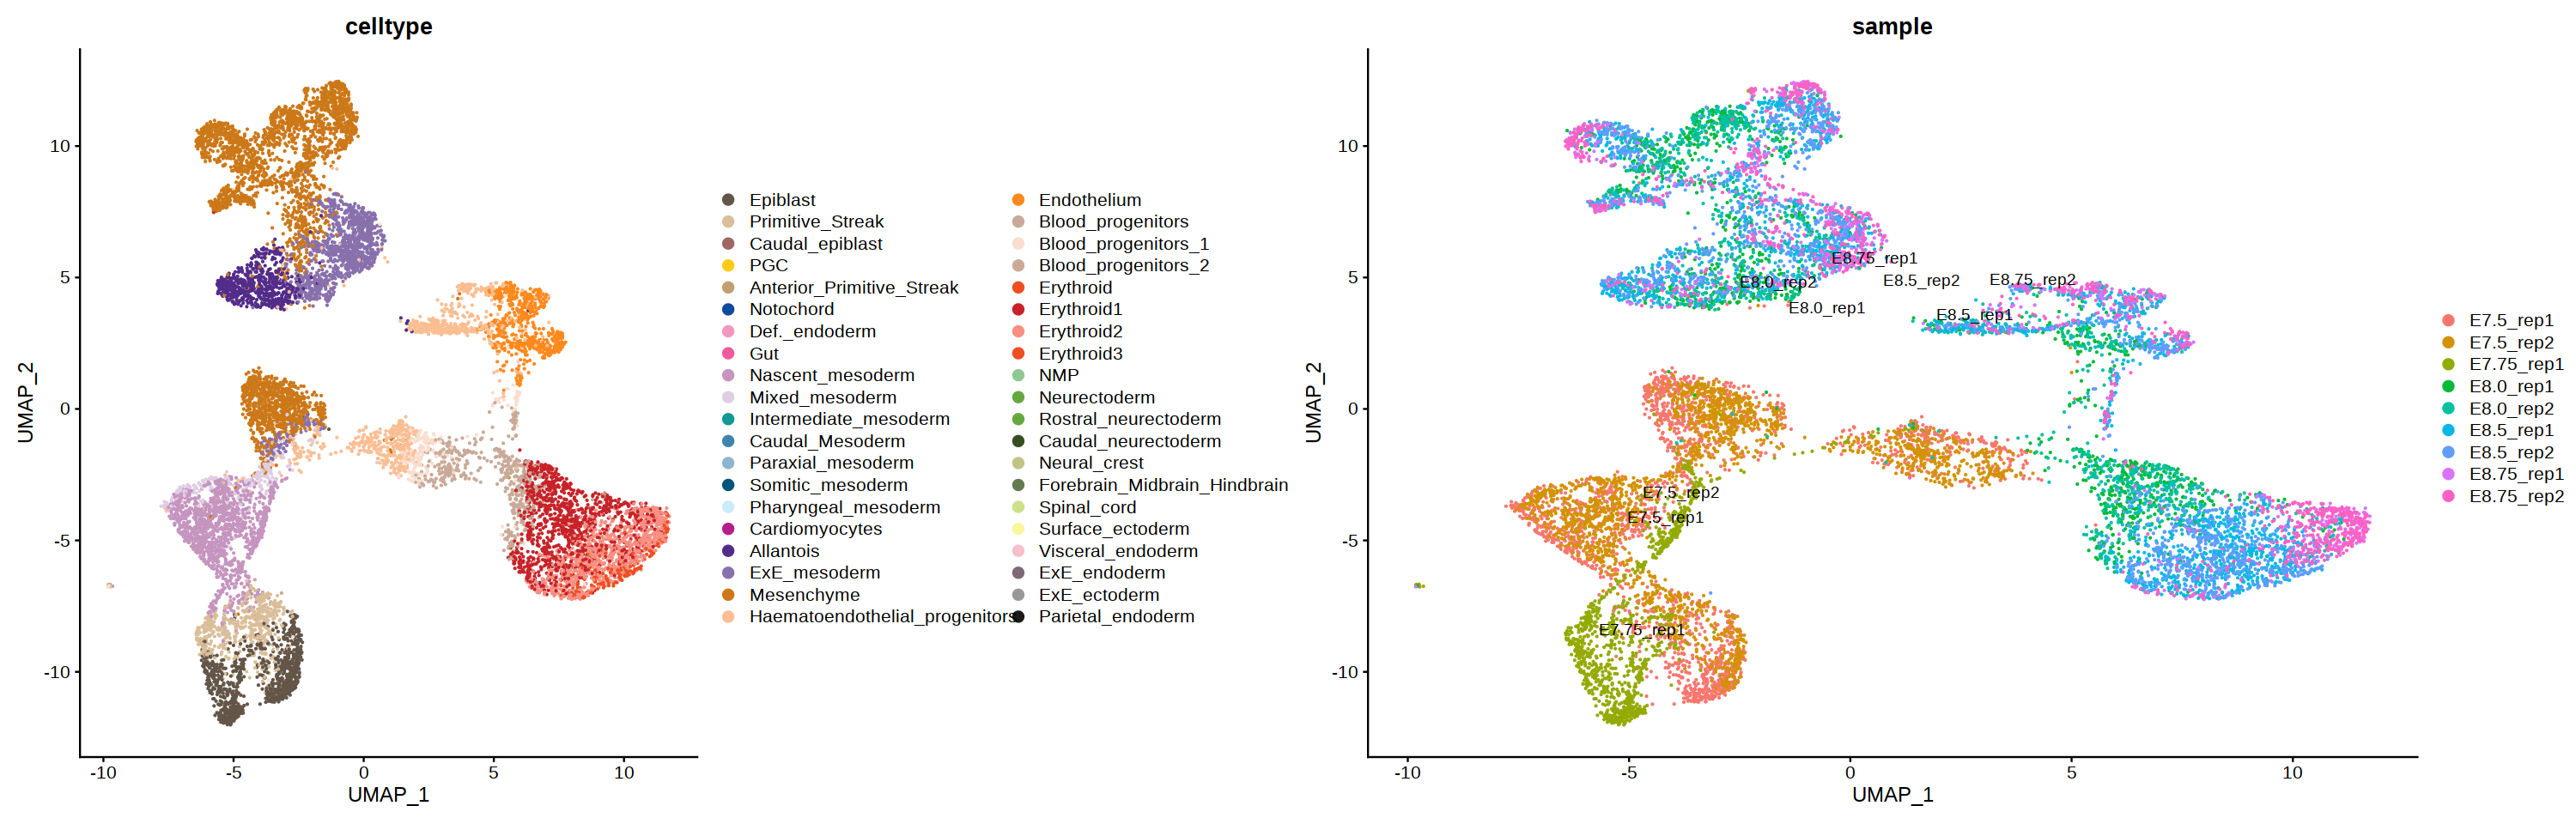

In [33]:
ggarrange(p1, p2)